## Обработка выбросов

Выбросы, или аномальные значения, представляют собой отклонения в данных, которые значительно отличаются от общего паттерна наблюдений. Они могут вносить существенные искажения в статистику и результаты анализа данных, делая важным их обнаружение и обработку. Выбросы могут возникнуть по различным причинам, включая ошибки в данных, аномалии в измерениях, или внештатные события.



<img src="https://www.writerscentre.com.au/wp-content/uploads/2020/05/diff.jpg" alt="min max formula" width="500" height="400">

Бывают разные виды выбросов, включая:

1. **Случайные выбросы:**
   - Это наблюдения, которые не подчиняются общему распределению данных и возникают случайным образом. Например, в медицинских измерениях роста, появление аномально низких значений может быть случайным результатом ошибки при измерении.

2. **Систематические выбросы:**
   - Эти выбросы обусловлены каким-то особым фактором или систематической ошибкой в сборе данных. Например, в экономических данных аномалии в росте дохода населения могут быть вызваны изменениями в методологии сбора данных.

3. **Выбросы из-за ошибок в данных:**
   - Ошибки в данных, такие как опечатки или некорректные измерения, могут привести к появлению выбросов. Например, в базе данных о температуре на кухне значения, сильно отличающиеся от общего тренда, могут быть результатом технической неисправности при измерении.

4. **Аномалии из-за внештатных событий:**
   - Выбросы могут возникнуть из-за внештатных событий, таких как стихийные бедствия, финансовые кризисы или другие неожиданные изменения условий. Например, в продажах товаров выбросы могут быть вызваны внезапным изменением потребительского спроса из-за внештатных обстоятельств.

Определение и обработка выбросов становятся важным этапом анализа данных, направленным на создание более точных и надежных моделей и выводов.

 Различные методы, включая статистические и машинное обучение, могут использоваться для выявления и управления этими аномалиями.

1. **Метод межквартильного размаха (IQR):**
   - Рассчитывается межквартильный размах (разница между третьим и первым квартилями). Выбросами считаются значения, находящиеся за пределами границ межквартильного размаха.
   - Формула: IQR = Q3 - Q1, выбросы: Нижняя граница = Q1 - k * IQR, Верхняя граница = Q3 + k * IQR, где k — коэффициент, обычно принимаемый равным 1.5, 3, или другим в зависимости от задачи.

2. **Z-оценка:**
   - Используется стандартная Z-оценка, чтобы определить, насколько далеко значение отклонено от среднего значения в терминах стандартных отклонений. Значения, которые находятся за пределами определенного порога (например, 3 стандартных отклонений), могут считаться выбросами.

3. **Метод крайних значений (Tukey's Fences):**
   - Этот метод схож с методом межквартильного размаха, но определяет выбросы на основе более сложной формулы. Границы определяются как
   
   Нижняя граница = Q1 - k * IQR и  Верхняя граница = Q3 + k * IQR, где k выбирается в зависимости от задачи.

4. **Метод обнаружения аномалий с использованием машинного обучения:**
   - Методы машинного обучения, такие как изолирующий лес (Isolation Forest) и одноклассовые методы, могут использоваться для выявления аномалий и выбросов в данных. Они основываются на том, что аномальные точки обычно имеют отличные характеристики.

5. **Визуальный анализ:**
   - Использование графиков, таких как ящик с усами (box plot) или диаграмма рассеяния (scatter plot), может помочь выявить выбросы визуально.

Выбор конкретной стратегии определения выбросов зависит от характера данных, предметной области и целей анализа. Важно оценить эффективность выбранного метода и учитывать особенности конкретной задачи.

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid", palette="rainbow")
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path = '/content/drive/MyDrive/itmo_ai_minor_2026(autumn)/Lesson7/data/'

In [7]:
df_normal = pd.read_csv(f"{path}water_potability.csv")

In [8]:
df_skew = pd.read_csv(f"{path}train.csv")

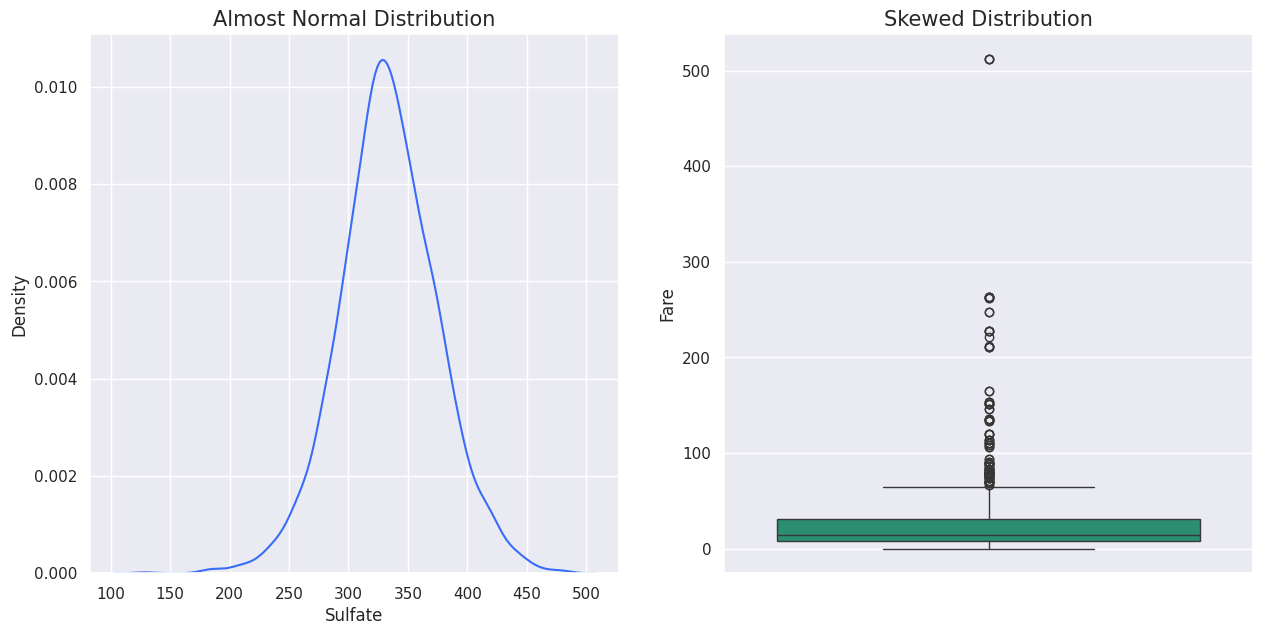

In [34]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.title("Almost Normal Distribution", fontsize=15)
sns.kdeplot(data = df_normal["Sulfate"])
plt.subplot(1,2,2)
plt.title("Skewed Distribution", fontsize=15)
sns.boxplot(data = df_skew["Fare"], palette="Dark2")
plt.show()

### Как убрать выбросы?

1. Trimming - Обрезка - это метод отсечения или избавления от выбросов в конце набора данных. Это проще, чем все остальные методы.
2. Capping - Усечение - это установка предела для признака и установка значения всех промахов, превышающих предел, на значение предела.

Предположим, что в наборе данных об успеваемости студентов 98% учащихся набрали меньше 60 баллов, но только 2% - больше 85 баллов. В данном примере эти 2% студентов являются выбросами.

Так, в примере со студентом мы установим предельное количество баллов и изменим оценку 2%-ного студента на это значение. Например, 75 - это максимальный предел, который мы установили. Оценка 2% студентов-аутсайдеров будет установлена на 75.


### Обрезка & Стандартное отклонение

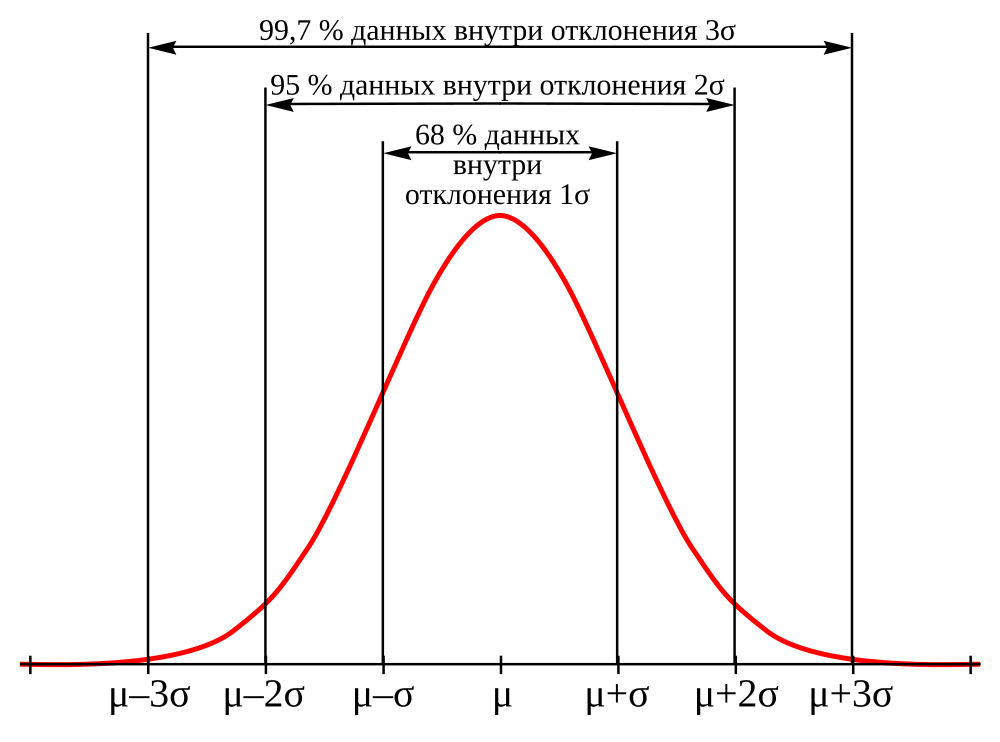

In [10]:
# определим нижний и верхний пределы
# lower_limit = Q1 - 1.5 * IQR
# upper_limit = Q3 + 1.5 * IQR
norm_upper_limit = df_normal["Sulfate"].mean() + 3 * df_normal["Sulfate"].std()
norm_lower_limit = df_normal["Sulfate"].mean() - 3 * df_normal["Sulfate"].std()

In [24]:
norm_lower_limit, norm_upper_limit

(np.float64(209.52525522579546), np.float64(458.02629799583156))

In [12]:
df_normal.shape

(3276, 10)

In [28]:
# отсекаем выбросы и получаем распределение с 3 стандартными отклонениями
df_normal_new = df_normal[df_normal["Sulfate"].between(norm_lower_limit, norm_upper_limit)]
df_normal_new

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
...,...,...,...,...,...,...,...,...,...,...
3267,8.989900,215.047358,15921.412018,6.297312,312.931022,390.410231,9.899115,55.069304,4.613843,1
3268,6.702547,207.321086,17246.920347,7.708117,304.510230,329.266002,16.217303,28.878601,3.442983,1
3269,11.491011,94.812545,37188.826022,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1
3270,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712,1


In [ ]:
df_normal

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


<Axes: >

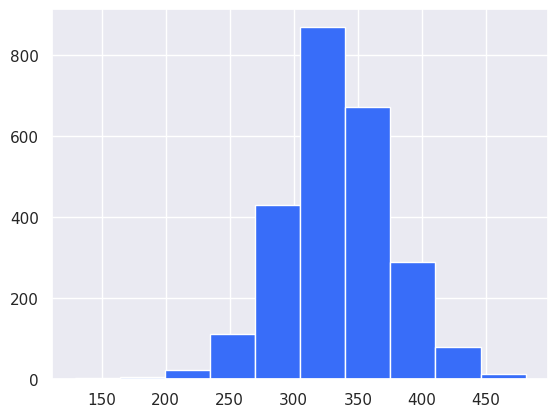

In [25]:
df_normal["Sulfate"].hist()

In [21]:
df_normal[(df_normal["Sulfate"] <= norm_lower_limit)]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
253,6.800119,242.008082,39143.403329,9.501695,187.170714,376.456593,11.432466,73.777275,3.854940,1
272,6.512737,229.263861,22475.046873,12.580026,192.033592,479.501279,9.983462,66.668576,4.612964,1
275,5.324942,280.089655,35344.658047,13.043806,180.206746,392.421496,10.504820,55.084668,4.427138,1
351,8.848586,188.919983,32033.332019,13.127000,182.397370,479.791975,12.070444,77.671337,4.014682,1
365,4.788861,234.893703,28174.620516,10.850036,187.424131,444.854321,11.784799,89.010974,2.896852,1
385,5.541979,185.671874,20143.065262,10.236176,209.471058,517.935786,18.464015,49.371319,3.672976,1
1366,5.754213,241.602430,31871.291239,7.299302,203.444521,495.945344,22.763707,71.428978,5.920234,0
1523,6.903817,258.526842,35455.709612,4.881377,206.247229,318.622622,13.961740,65.866679,3.867843,1
1554,8.942046,215.673786,56488.672413,3.231438,129.000000,541.915468,9.313771,70.828374,4.354288,1
1860,4.477092,236.282490,26843.470364,4.842658,207.890482,456.979772,16.225706,74.035695,4.327680,0


In [22]:
df_normal[(df_normal["Sulfate"] >= norm_upper_limit)]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
1537,7.381758,203.460302,1372.091043,11.129154,475.737460,361.342496,16.548438,55.132546,3.338022,1
1563,NaN,195.540967,4142.499001,9.892703,462.474215,435.418245,15.846048,NaN,3.612919,1
1605,7.445189,150.775723,4168.196994,10.573403,476.539717,355.578481,15.352425,74.760976,2.745804,1
1743,8.895574,107.383327,27622.746268,6.163320,460.107069,444.929584,13.995136,78.348415,4.754235,0
1773,8.518532,128.263466,32018.289631,6.058740,458.441072,554.139037,15.976196,87.471821,4.147169,0
2318,5.057736,137.689344,11229.137777,6.411410,481.030642,580.095225,15.390304,43.882514,3.163936,1


In [20]:
df_normal[(df_normal["Sulfate"] <= norm_lower_limit) | (df_normal["Sulfate"] >= norm_upper_limit)]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
253,6.800119,242.008082,39143.403329,9.501695,187.170714,376.456593,11.432466,73.777275,3.854940,1
272,6.512737,229.263861,22475.046873,12.580026,192.033592,479.501279,9.983462,66.668576,4.612964,1
275,5.324942,280.089655,35344.658047,13.043806,180.206746,392.421496,10.504820,55.084668,4.427138,1
351,8.848586,188.919983,32033.332019,13.127000,182.397370,479.791975,12.070444,77.671337,4.014682,1
365,4.788861,234.893703,28174.620516,10.850036,187.424131,444.854321,11.784799,89.010974,2.896852,1
385,5.541979,185.671874,20143.065262,10.236176,209.471058,517.935786,18.464015,49.371319,3.672976,1
1366,5.754213,241.602430,31871.291239,7.299302,203.444521,495.945344,22.763707,71.428978,5.920234,0
1523,6.903817,258.526842,35455.709612,4.881377,206.247229,318.622622,13.961740,65.866679,3.867843,1
1537,7.381758,203.460302,1372.091043,11.129154,475.737460,361.342496,16.548438,55.132546,3.338022,1
1554,8.942046,215.673786,56488.672413,3.231438,129.000000,541.915468,9.313771,70.828374,4.354288,1


In [29]:
df_normal.shape, df_normal_new.shape

((3276, 10), (2478, 10))

In [ ]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.title("Almost Normal Distribution", fontsize=15)
sns.kdeplot(data = df_normal["Sulfate"])
plt.subplot(1,2,2)
plt.title("Skewed Distribution", fontsize=15)
sns.boxplot(data = df_skew["Fare"], palette="Dark2")
plt.show()

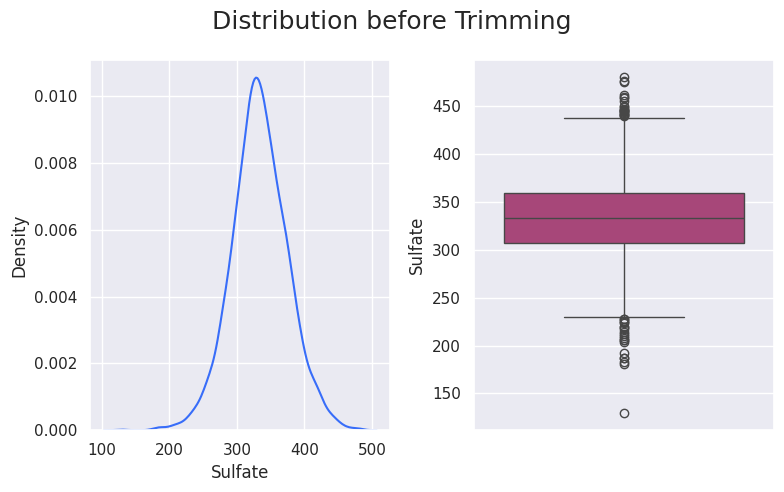

In [36]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution before Trimming", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_normal["Sulfate"])
plt.subplot(1,2,2)
sns.boxplot(data = df_normal["Sulfate"], palette="magma")
plt.tight_layout()
plt.show()

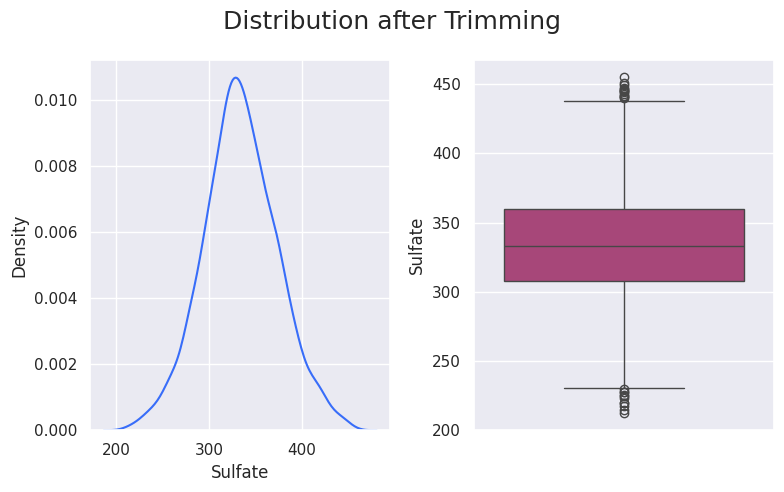

In [37]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution after Trimming",fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_normal_new["Sulfate"])
plt.subplot(1,2,2)
sns.boxplot(data = df_normal_new["Sulfate"], palette="magma")
plt.tight_layout()
plt.show()

Распределение не пострадало при использовании этого метода. Кроме того, мы избавились от выбросов. Одна плохая черта этого метода - потеря информации. Мы избавились от соответствующей информации о признаках, которая могла бы быть полезной для модели. Однако, как и отбрасывание нулевых значений, этот метод может привести к потере информации.

Примеры, когда просто отбрасываем строки с выбросами, могут включать ситуации, когда:

1. **Ошибка в измерениях:**
   - В медицинском исследовании, где выявленные значения явно ошибочны или некорректны, такие как нереалистично высокие или низкие показатели физиологических параметров.

2. **Технические сбои при измерении:**
   - В данных по измерениям с использованием технического оборудования, где выбросы могут быть следствием временных сбоев в работе оборудования.




***

### Усечение & Интерквартильный размах

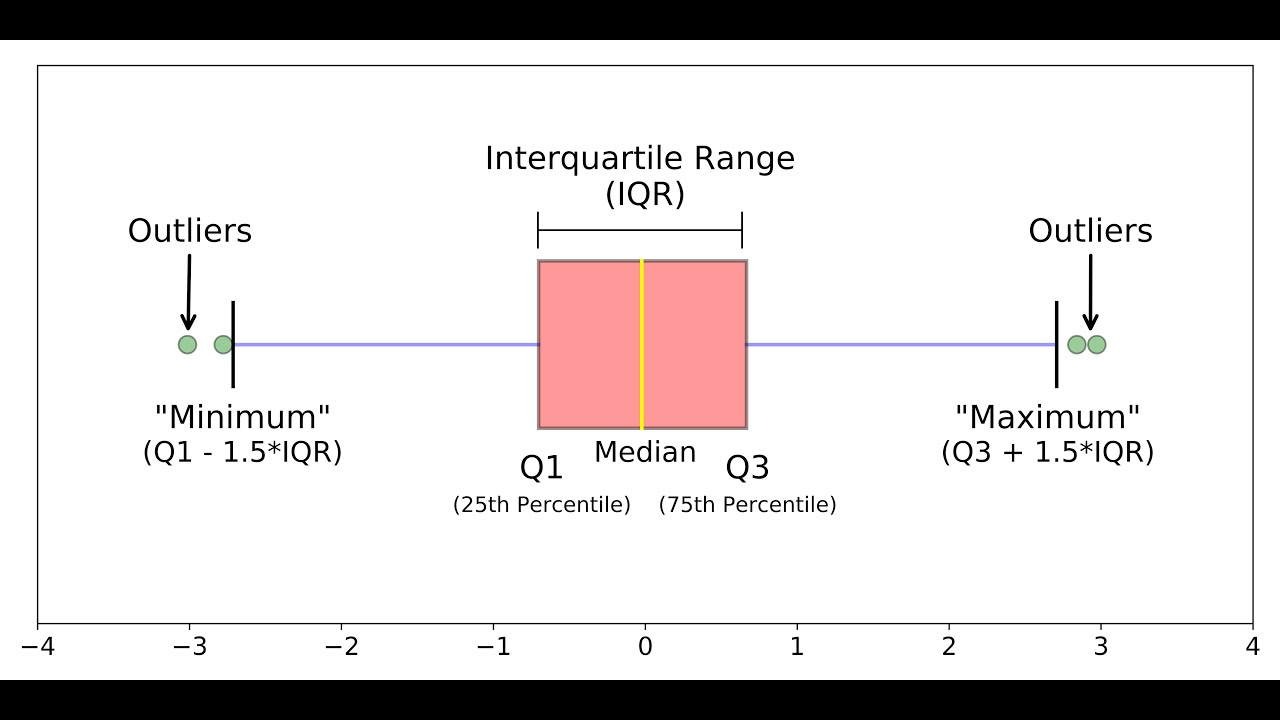

In [39]:
# ищем Q1(25 перцентиль) и Q3(75 перцентиль)
q1 = df_skew["Fare"].quantile(0.25)
q3 = df_skew["Fare"].quantile(0.75)

In [40]:
# определение значения межквартильного интервала
IQR = q3 - q1

In [41]:
# определяем максимальную и минималную границы
max_limit = q3 + (3 * IQR)
min_limit = q1 - (3 * IQR)

In [47]:
df_skew_loc = df_skew.copy()

In [48]:
df_skew_loc.loc[(df_skew_loc["Fare"] > max_limit, "Fare")] = max_limit

In [53]:
max_limit

np.float64(100.2688)

In [54]:
df_skew_loc[df_skew_loc["Fare"] > max_limit-20]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,100.2688,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,100.2688,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.4750,C83,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,100.2688,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...,...
820,821,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
835,836,1,1,"Compton, Miss. Sara Rebecca",female,39.0,1,1,PC 17756,83.1583,E49,C
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,100.2688,NaN,S


In [55]:
# усечение
df_skew_new = pd.DataFrame(np.where(df_skew["Fare"] > max_limit, max_limit,
         (np.where(df_skew["Fare"] < min_limit, min_limit, df_skew["Fare"]))), columns=["Fare"])

In [60]:
df_skew.loc[df_skew["Fare"] > 200]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


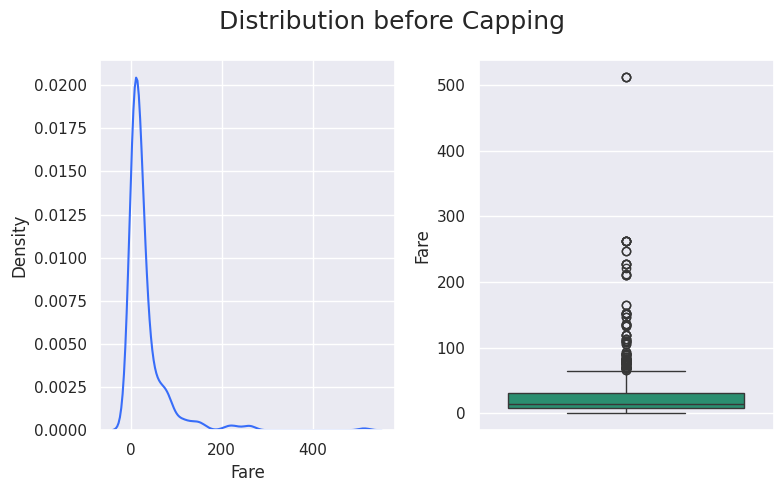

In [56]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution before Capping", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_skew["Fare"], palette="cool")
plt.subplot(1,2,2)
sns.boxplot(data = df_skew["Fare"], palette="Dark2")
plt.tight_layout()
plt.show()

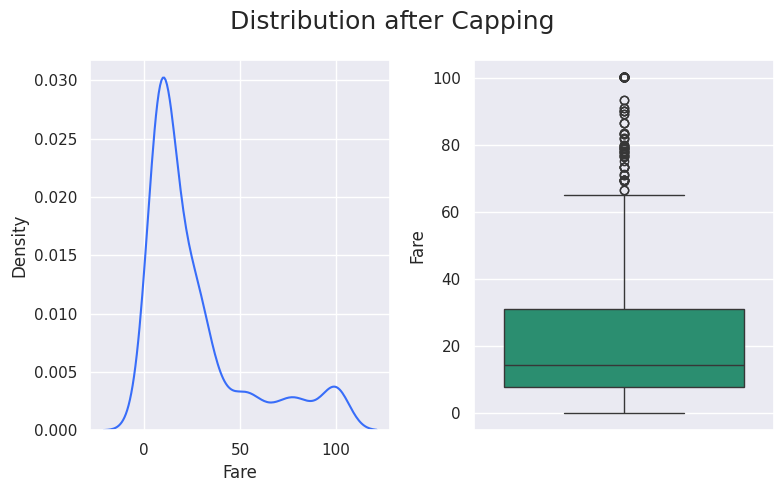

In [57]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution after Capping",fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_skew_new["Fare"], palette="cool")
plt.subplot(1,2,2)
sns.boxplot(data = df_skew_new["Fare"], palette="Dark2")
plt.tight_layout()
plt.show()

> Обратите внимание, как мы избавились от выбросов. Кроме того, поскольку значения выбросов были заменены максимальным и минимальным пределом, обратите внимание, как на PDF или KDEplot появляется выпуклость или больше значений вблизи 60-80.

Выбросы часто рассматриваются при работе с асимметричными (скошенными) распределениями, такими как скошенное вправо (positive skewness) или скошенное влево (negative skewness). Вот несколько примеров ситуаций, когда можно рассмотреть удаление выбросов для асимметричного распределения:

1. **Доходы населения:**
   - Распределение доходов населения часто является скосным вправо из-за наличия небольшого числа людей с очень высоким доходом. Удаление выбросов может быть оправданным, если цель анализа — изучение общего распределения доходов среди большинства населения.

2. **Время ответа в системе обслуживания:**
   - Если мы измеряем время ответа в системе обслуживания клиентов, то из-за случайных факторов или возможных технических проблем, время ответа может быть искажено. Удаление выбросов в этом случае может помочь более точно оценить типичное время ожидания.

3. **Продажи товаров:**
   - В случае продаж, где большинство транзакций может иметь небольшие суммы, но есть также транзакции с очень высокими суммами (например, крупные корпоративные заказы), удаление выбросов может быть целесообразным для более точного анализа общих тенденций в продажах.

4. **Результаты экспериментов:**
   - В научных экспериментах, где измеряются значения событий, смещенных вправо или влево, выбросы могут возникнуть из-за систематических ошибок или неожиданных факторов. Удаление выбросов может помочь обеспечить более чистое представление результатов эксперимента.

Важно отметить, что принятие решения об удалении выбросов зависит от целей анализа и контекста конкретной задачи. При этом также важно оценивать влияние удаления выбросов на статистические характеристики данных и давать обоснование выбора метода обработки.

### Метод перцентилей

В методе процентилей вы определяете конкретный порог в процентилях. Можно использовать ту же функцию, которую использовали для q1 и q2 при определении IQR.

Определяем определенный порог, например, все, что выше 98 перцентиля и ниже 2 перцентиля, будет считаться выбросом. Затем можно использовать обрезку или усечение, чтобы справиться с ними.

Процентный метод является произвольным, и придется определять значение вручную, и здесь вам очень помогут знания домена. Знание домена - самая сильная опора в разработке функций. Если вы не знаете о данных, начните гуглить и узнавать о них больше. Узнайте больше о функциях, и у вас разовьется базовая интуиция, и вы, возможно, найдете собственный способ обработки выбросов. Экспериментируйте, делайте пробы и ошибки и получайте удовольствие от работы с ML. Продолжайте работать!

## Ссылки
https://www.kaggle.com/code/marcinrutecki/outlier-detection-methods#6.-Isolation-Forest

https://www.dmitrymakarov.ru/data-analysis/outliers-09/